In [1]:
import tensorflow as tf

In [2]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D
from keras.applications import ResNet50V2
from keras.applications.mobilenet_v2 import preprocess_input, decode_predictions
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

# Set random seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Define Xception-based model function
def get_ResNet50V2_based_model():
    base_model = ResNet50V2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

    inputs = tf.keras.Input(shape=(224, 224, 3))
    x = base_model(inputs, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(units=1024, activation='relu')(x)
    outputs = tf.keras.layers.Dense(units=1, activation='sigmoid')(x)
    model = tf.keras.Model(inputs=inputs, outputs=outputs)

    opt = Adam(learning_rate=0.0001)
    model.compile(loss='binary_crossentropy', optimizer=opt, metrics=['accuracy'])

    return model

In [4]:

# Load and preprocess image function
def load_and_preprocess_image(image_path):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [224, 224])
    img = tf.cast(img, tf.float32) / 255.0
    return img

# Predict with threshold function
def predict_with_threshold(model, image_path, threshold=0.5):
    img = load_and_preprocess_image(image_path)
    img = np.expand_dims(img, axis=0)

    prediction = model.predict(img)[0][0]

    print(f"Raw Prediction Score: {prediction:.4f}.")

    if prediction >= threshold:
        pred_class = 'real'
    else:
        pred_class = 'fake'

    print(f"Predicted Class ({pred_class}), Probability - {prediction:.4f}.")

In [5]:
if __name__ == "__main__":
    # Create Xception model
    ResNet50V2_model = get_ResNet50V2_based_model()

94668760/94668760 [==============================] - 14s 0us/step


In [7]:
# Set up data generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    rotation_range=10.,
    width_shift_range=0.1,
    height_shift_range=0.1)

validation_datagen = ImageDataGenerator(rescale=1./255)

# Flow from directory
train_generator = train_datagen.flow_from_directory(
    directory='C:\\Users\\debas\\Downloads\\Datasets\\Real vs Fake Faces - 10k\\7525\\train',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary')

validate_generator = validation_datagen.flow_from_directory(
    directory='C:\\Users\\debas\\Downloads\\Datasets\\Real vs Fake Faces - 10k\\7525\\valid',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary')

Found 7500 images belonging to 2 classes.
Found 1250 images belonging to 2 classes.


In [8]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Model and compilation
model = get_ResNet50V2_based_model()

# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

# Fit model
history = model.fit(train_generator, 
          validation_data=validate_generator, 
          epochs=40, 
          callbacks=[early_stopping, reduce_lr])

Epoch 1/40
235/235 [==============================] - 272s 1s/step - loss: 0.6284 - accuracy: 0.6509 - val_loss: 0.5611 - val_accuracy: 0.7464 - lr: 1.0000e-04
Epoch 2/40
235/235 [==============================] - 238s 1s/step - loss: 0.5537 - accuracy: 0.7215 - val_loss: 0.4974 - val_accuracy: 0.7664 - lr: 1.0000e-04
Epoch 3/40
235/235 [==============================] - 430s 2s/step - loss: 0.5126 - accuracy: 0.7493 - val_loss: 0.4822 - val_accuracy: 0.7752 - lr: 1.0000e-04
Epoch 4/40
235/235 [==============================] - 61s 258ms/step - loss: 0.4518 - accuracy: 0.7903 - val_loss: 0.4107 - val_accuracy: 0.8080 - lr: 1.0000e-04
Epoch 5/40
235/235 [==============================] - 63s 268ms/step - loss: 0.4036 - accuracy: 0.8177 - val_loss: 0.3564 - val_accuracy: 0.8504 - lr: 1.0000e-04
Epoch 6/40
235/235 [==============================] - 70s 299ms/step - loss: 0.3737 - accuracy: 0.8343 - val_loss: 0.4325 - val_accuracy: 0.7984 - lr: 1.0000e-04
Epoch 7/40
235/235 [==============

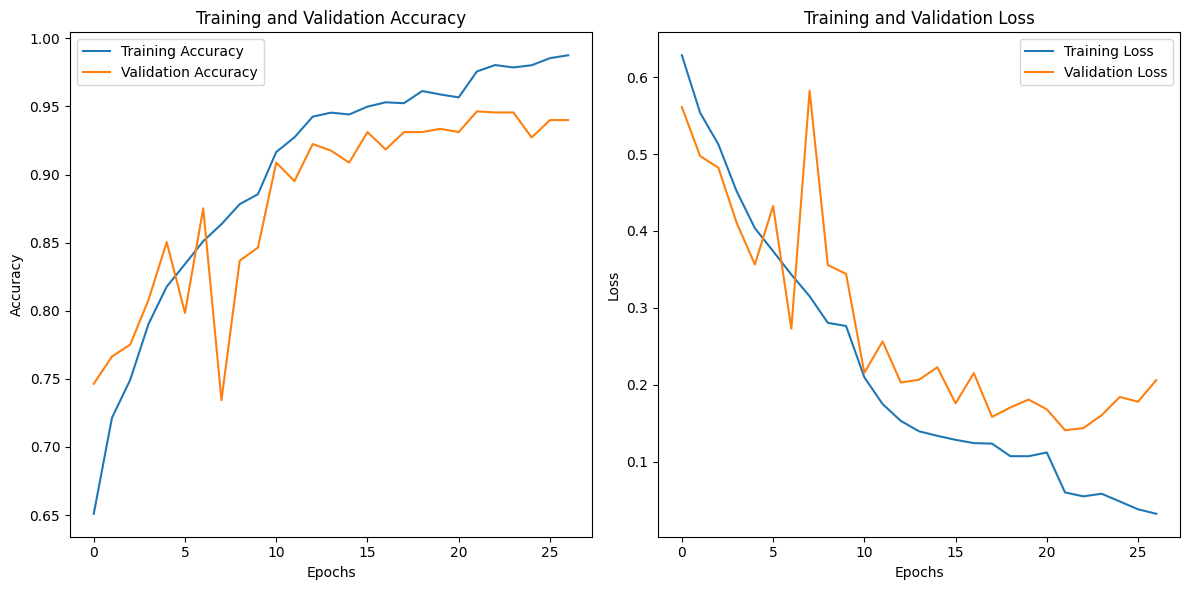

In [9]:
import matplotlib.pyplot as plt

# Combine the training and validation metrics from both histories
history_combined = {}
for key in history.history.keys():
    history_combined[key] = history.history[key]

# Create a figure and axis
plt.figure(figsize=(12, 6))

# Plot the combined training and validation accuracy
plt.subplot(1, 2, 1)  # 1 row, 2 columns, 1st subplot
plt.plot(history_combined['accuracy'], label='Training Accuracy')
plt.plot(history_combined['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

# Plot the combined training and validation loss
plt.subplot(1, 2, 2)  # 1 row, 2 columns, 2nd subplot
plt.plot(history_combined['loss'], label='Training Loss')
plt.plot(history_combined['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

# Show the plots
plt.tight_layout()  # Adjusts the spacing between subplots
plt.show()


In [10]:
model.save('C:\\Users\\debas\\Downloads\\Datasets\\Real vs Fake Faces - 10k\\7525\\7525ResNet50V2_model.h5')

In [11]:
# Load the test dataset
test_generator = validation_datagen.flow_from_directory(
    directory='C:\\Users\\debas\\Downloads\\Datasets\\Real vs Fake Faces - 10k\\7525\\test',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False  # Important: set shuffle to False for evaluation
)

# Evaluate the model on the test dataset
test_loss, test_accuracy = model.evaluate(test_generator)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Found 1250 images belonging to 2 classes.
40/40 [==============================] - 3s 59ms/step - loss: 0.1577 - accuracy: 0.9400
Test Loss: 0.1577
Test Accuracy: 0.9400


40/40 [==============================] - 3s 61ms/step


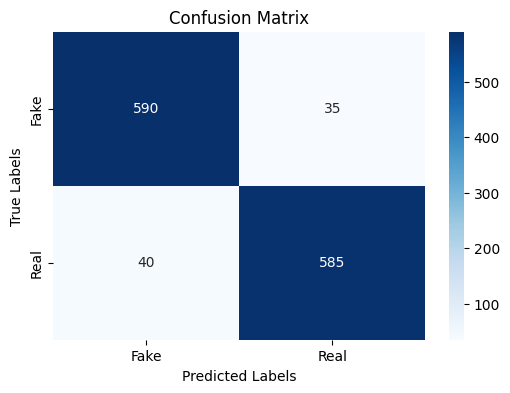

              precision    recall  f1-score   support

        Fake       0.94      0.94      0.94       625
        Real       0.94      0.94      0.94       625

    accuracy                           0.94      1250
   macro avg       0.94      0.94      0.94      1250
weighted avg       0.94      0.94      0.94      1250



In [12]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Make predictions on the test dataset
predictions = model.predict(test_generator)
predicted_classes = (predictions > 0.5).astype(int)  # Assuming binary classification

# Step 2: Extract true labels from the test generator
true_classes = test_generator.classes

# Step 3: Build confusion matrix
conf_matrix = confusion_matrix(true_classes, predicted_classes)

# Plotting the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

# Step 4: Generate Classification Report (Optional)
class_report = classification_report(true_classes, predicted_classes, target_names=['Fake', 'Real'])
print(class_report)


In [13]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Assuming binary classification with class labels 0 and 1
precision = precision_score(true_classes, predicted_classes)
recall = recall_score(true_classes, predicted_classes)
f1 = f1_score(true_classes, predicted_classes)

print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-Score: {f1:.4f}')

Precision: 0.9435
Recall: 0.9360
F1-Score: 0.9398


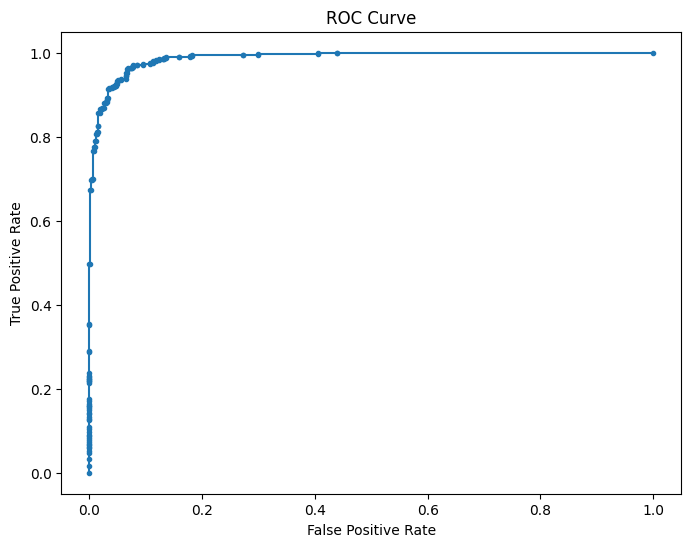

ROC AUC: 0.9878


In [16]:
from sklearn.metrics import roc_auc_score, roc_curve

# Compute ROC AUC
roc_auc = roc_auc_score(true_classes, predictions)

# Compute ROC curve
fpr, tpr, _ = roc_curve(true_classes, predictions)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, marker='.')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

print(f'ROC AUC: {roc_auc:.4f}')


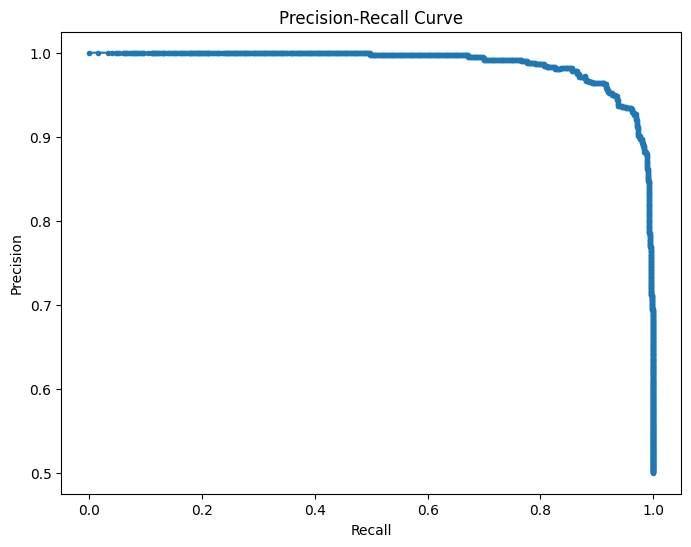

Precision-Recall AUC: 0.9880


In [17]:
from sklearn.metrics import average_precision_score, precision_recall_curve

# Compute AUC PR
auc_pr = average_precision_score(true_classes, predictions)

# Compute Precision-Recall curve
precision_pr, recall_pr, _ = precision_recall_curve(true_classes, predictions)

# Plot Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall_pr, precision_pr, marker='.')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()

print(f'Precision-Recall AUC: {auc_pr:.4f}')


In [18]:
from sklearn.metrics import matthews_corrcoef

mcc = matthews_corrcoef(true_classes, predicted_classes)
print(f'Matthews Correlation Coefficient: {mcc:.4f}')


Matthews Correlation Coefficient: 0.8800


In [19]:
# Compute ROC curve
fpr, tpr, _ = roc_curve(true_classes, predictions)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, marker='.')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.savefig('C:\\Users\\debas\\Downloads\\Datasets\\Real vs Fake Faces - 10k\\7525\\ResNet50V2roc_curve.png')  # Save the figure
plt.close()  # Close the figure to free memory


In [20]:
# Compute Precision-Recall curve
precision_pr, recall_pr, _ = precision_recall_curve(true_classes, predictions)

# Plot Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall_pr, precision_pr, marker='.')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.savefig('C:\\Users\\debas\\Downloads\\Datasets\\Real vs Fake Faces - 10k\\7525\\ResNet50V2precision_recall_curve.png')  # Save the figure
plt.close()  # Close the figure to free memory


In [21]:
# Plotting the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.savefig('C:\\Users\\debas\\Downloads\\Datasets\\Real vs Fake Faces - 10k\\7525\\ResNet50V2confusion_matrix.png')  # Save the figure
plt.close()  # Close the figure to free memory


In [ ]:
import tensorflow as tf

# Assuming `xception_model` is your trained Xception model
# and `xception_save_path` is the path where you want to save the model
xception_save_path ='C:\\Users\\debas\\Downloads\\Datasets\\Real vs Fake Faces - 10k\\7030',

# Convert the Keras model to a TensorFlow SavedModel
tf.saved_model.save(xception_model, xception_save_path)

print(f"Model saved to {xception_save_path}")

1/1 [==============================] - 1s 997ms/step


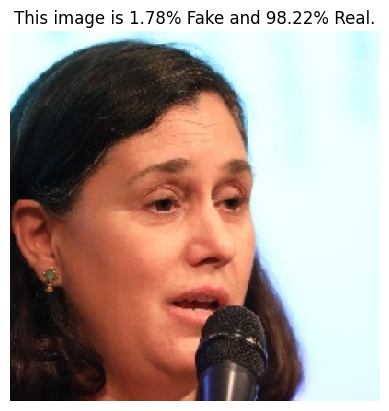

In [22]:
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import numpy as np
test_image = image.load_img('C:\\Users\\debas\\Downloads\\Datasets\\Real vs Fake Faces - 10k\\7525\\test\\real\\47202.jpg', target_size=(224, 224, 3))
plt.imshow(test_image)
plt.axis('off')

test_image_arr = image.img_to_array(test_image)
test_image_arr = np.expand_dims(test_image, axis=0)
test_image_arr = test_image_arr/255.

result = model.predict(test_image_arr)

plt.title(f"This image is {100 * (1 - result[0][0]):.2f}% Fake and {100 * result[0][0]:.2f}% Real.")
plt.savefig('C:\\Users\\debas\\Downloads\\Datasets\\Real vs Fake Faces - 10k\\real test')

1/1 [==============================] - 0s 27ms/step


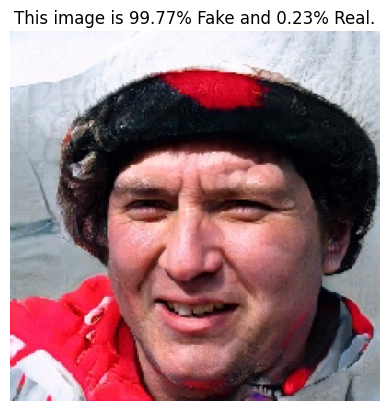

In [23]:
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import numpy as np
test_image = image.load_img('C:\\Users\\debas\\Downloads\\Datasets\\Real vs Fake Faces - 10k\\7525\\test\\fake\\JN0UOYAWMI.jpg', target_size=(224, 224, 3))
plt.imshow(test_image)
plt.axis('off')

test_image_arr = image.img_to_array(test_image)
test_image_arr = np.expand_dims(test_image, axis=0)
test_image_arr = test_image_arr/255.
result = model.predict(test_image_arr)

plt.title(f"This image is {100 * (1 - result[0][0]):.2f}% Fake and {100 * result[0][0]:.2f}% Real.")
plt.savefig('C:\\Users\\debas\\Downloads\\Datasets\\Real vs Fake Faces - 10k\\fake test')

In [ ]:
from tensorflow.keras.models import load_model
model = load_model('C:\\Users\\debas\\Downloads\\Datasets\\real_vs_fake\\2nd Paper (3rd ViT Model)\\3rdvitmodel.h5')
test_loss, test_acc = model.evaluate(test_generator)